In [1]:
pip install imbalanced-learn

In [3]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


Dataset Shape
(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

     

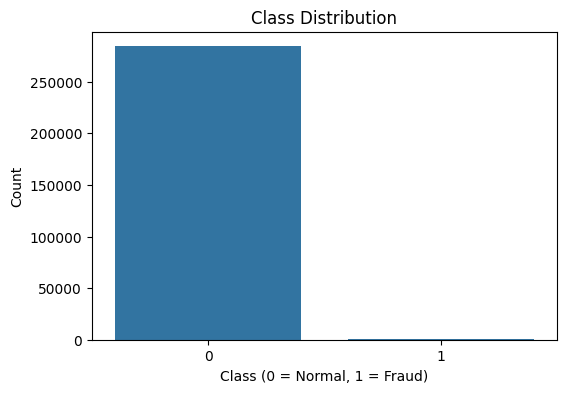


Before SMOTE
Accuracy : 0.9991573329588147
Precision: 0.8289473684210527
Recall   : 0.6428571428571429
F1 Score : 0.7241379310344828

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



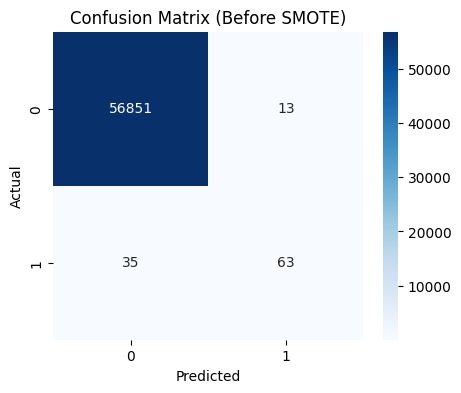


Applying SMOTE...

After SMOTE Class Distribution
Class
0    227451
1    227451
Name: count, dtype: int64


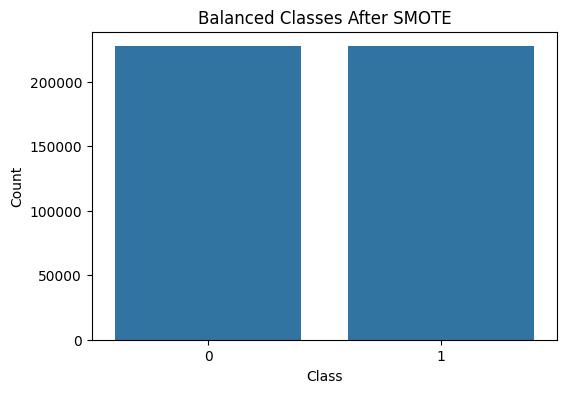


After SMOTE
Accuracy : 0.9742635441171307
Precision: 0.05813953488372093
Recall   : 0.9183673469387755
F1 Score : 0.10935601458080195

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



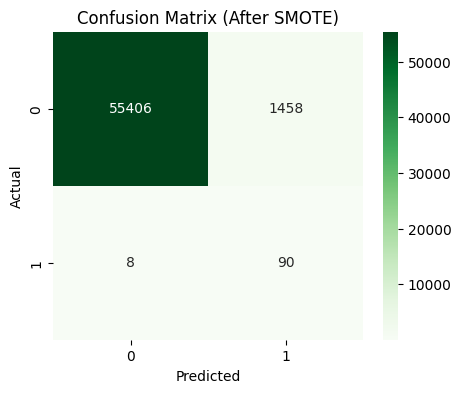


Performance Comparison

      Metric    Before     After
0   Accuracy  0.999157  0.974264
1  Precision  0.828947  0.058140
2     Recall  0.642857  0.918367
3   F1 Score  0.724138  0.109356


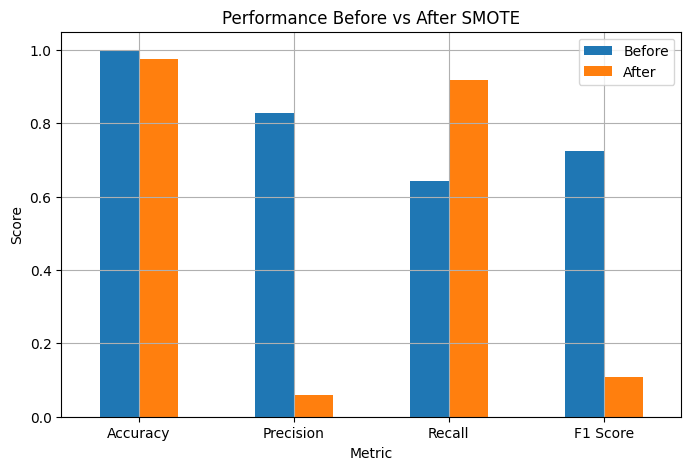


Task Completed Successfully!


In [4]:
# ======================================================
# Neurofive Solutions Week 5
# Handling Imbalanced Data using SMOTE
# ======================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

# ======================================================
# Load Dataset
# ======================================================

df = pd.read_csv("creditcard.csv")

print("="*60)
print("Dataset Shape")
print(df.shape)

print("="*60)
print(df.head())

# ======================================================
# Check Missing Values
# ======================================================

print("\nMissing Values\n")
print(df.isnull().sum())

# ======================================================
# Class Distribution
# ======================================================

print("\nClass Distribution")

print(df["Class"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

# ======================================================
# Features and Target
# ======================================================

X = df.drop("Class", axis=1)

y = df["Class"]

# ======================================================
# Scale Amount and Time
# ======================================================

scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X[["Amount"]])
X["Time"] = scaler.fit_transform(X[["Time"]])

# ======================================================
# Train Test Split
# ======================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================================
# BEFORE SMOTE
# ======================================================

print("\n==============================")
print("Before SMOTE")
print("==============================")

model_before = LogisticRegression(max_iter=1000)

model_before.fit(X_train, y_train)

pred_before = model_before.predict(X_test)

acc_before = accuracy_score(y_test, pred_before)
prec_before = precision_score(y_test, pred_before)
rec_before = recall_score(y_test, pred_before)
f1_before = f1_score(y_test, pred_before)

print("Accuracy :", acc_before)
print("Precision:", prec_before)
print("Recall   :", rec_before)
print("F1 Score :", f1_before)

print("\nClassification Report\n")
print(classification_report(y_test, pred_before))

cm = confusion_matrix(y_test, pred_before)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix (Before SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ======================================================
# Apply SMOTE
# ======================================================

print("\nApplying SMOTE...")

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE Class Distribution")

print(pd.Series(y_train_smote).value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y_train_smote)
plt.title("Balanced Classes After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# ======================================================
# AFTER SMOTE
# ======================================================

print("\n==============================")
print("After SMOTE")
print("==============================")

model_after = LogisticRegression(max_iter=1000)

model_after.fit(X_train_smote, y_train_smote)

pred_after = model_after.predict(X_test)

acc_after = accuracy_score(y_test, pred_after)
prec_after = precision_score(y_test, pred_after)
rec_after = recall_score(y_test, pred_after)
f1_after = f1_score(y_test, pred_after)

print("Accuracy :", acc_after)
print("Precision:", prec_after)
print("Recall   :", rec_after)
print("F1 Score :", f1_after)

print("\nClassification Report\n")
print(classification_report(y_test, pred_after))

cm = confusion_matrix(y_test, pred_after)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens")
plt.title("Confusion Matrix (After SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ======================================================
# Comparison
# ======================================================

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Before":[
        acc_before,
        prec_before,
        rec_before,
        f1_before
    ],

    "After":[
        acc_after,
        prec_after,
        rec_after,
        f1_after
    ]
})

print("\nPerformance Comparison\n")

print(comparison)

comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Performance Before vs After SMOTE")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(True)

plt.show()

print("\nTask Completed Successfully!")
